# 06  ·  Results comparison

Pull the four saved-result JSONs and lay them side-by-side. This is the
notebook to look at if you only have time for one — every headline
number, the bar chart, the four confusion matrices, and the cross-subject
generalization gap, all in one place.

In [1]:
# Make the eeg_cognitive package importable when running this notebook
# directly out of a clone (no pip install required).
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


In [2]:
import json, os, numpy as np, matplotlib.pyplot as plt
RESULTS = '../results'

results = {}
for ds_name in ['motor_imagery', 'mental_arithmetic']:
    for m in ['fbcsp', 'eegnet']:
        path = os.path.join(RESULTS, f'{ds_name}_{m}.json')
        if os.path.exists(path):
            with open(path) as f:
                results[(ds_name, m)] = json.load(f)
        else:
            print(f'  missing: {path}')

print(f'loaded {len(results)} result files')


loaded 4 result files


## Headline table

In [3]:
print(f"{'dataset':22s} {'model':12s} {'acc':>14s} {'F1':>14s} {'kappa':>14s}")
print('-' * 78)
for (dsn, m), d in results.items():
    s = d['summary']
    name = 'FBCSP+LDA' if m == 'fbcsp' else 'EEGNet'
    acc = f"{s['acc_mean']*100:5.1f} ± {s['acc_std']*100:4.1f}"
    f1  = f"{s['f1_mean']*100:5.1f} ± {s['f1_std']*100:4.1f}"
    kp  = f"{s['kappa_mean']:+.3f} ± {s['kappa_std']:.3f}"
    print(f"{dsn:22s} {name:12s} {acc:>14s} {f1:>14s} {kp:>14s}")


dataset                model                   acc             F1          kappa
------------------------------------------------------------------------------
motor_imagery          FBCSP+LDA       99.4 ±  0.8    99.4 ±  0.8 +0.992 ± 0.010
motor_imagery          EEGNet          87.5 ± 13.0    87.6 ± 13.0 +0.833 ± 0.173
mental_arithmetic      FBCSP+LDA       98.1 ±  1.2    98.1 ±  1.2 +0.963 ± 0.023
mental_arithmetic      EEGNet          79.7 ± 23.6    74.4 ± 30.1 +0.594 ± 0.472


## Per-fold accuracy bar chart

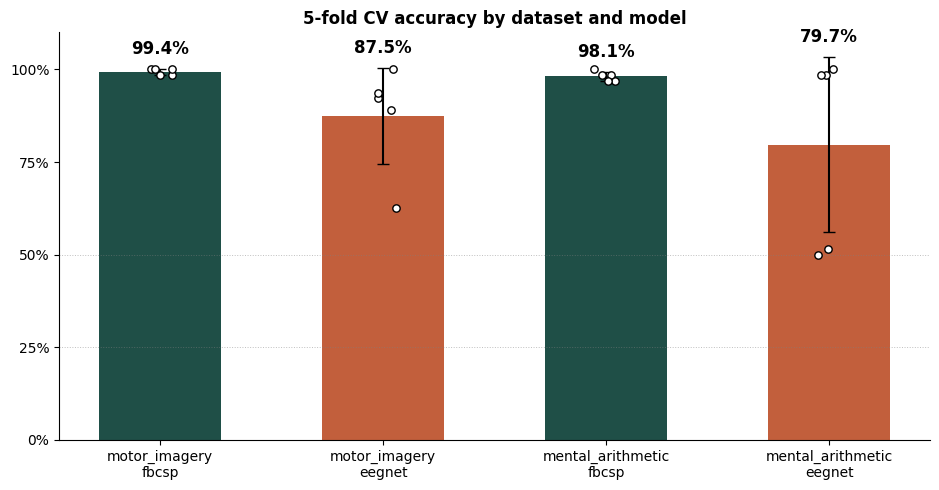

In [4]:
rows = []
for (dsn, m) in [('motor_imagery','fbcsp'), ('motor_imagery','eegnet'),
                 ('mental_arithmetic','fbcsp'), ('mental_arithmetic','eegnet')]:
    if (dsn, m) in results:
        rows.append((f'{dsn}\n{m}', results[(dsn, m)]['per_fold_accuracy'],
                     '#1F4F47' if m == 'fbcsp' else '#C25F3C'))

fig, ax = plt.subplots(figsize=(9.5, 5))
xs = np.arange(len(rows))
for x, (label, accs, color) in zip(xs, rows):
    m, sd = np.mean(accs), np.std(accs)
    ax.bar(x, m, color=color, width=0.55)
    ax.errorbar(x, m, yerr=sd, fmt='none', ecolor='black', capsize=4)
    jitter = np.random.default_rng(int(x*7+1)).uniform(-0.06, 0.06, len(accs))
    ax.scatter(x + jitter, accs, s=28, color='white', edgecolor='black', zorder=5)
    ax.text(x, m + sd + 0.04, f'{m*100:.1f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_xticks(xs); ax.set_xticklabels([r[0] for r in rows], fontsize=10)
ax.set_ylim(0, 1.10); ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.axhline(0.25, color='gray', linestyle=':', alpha=0.5, linewidth=0.7)
ax.axhline(0.50, color='gray', linestyle=':', alpha=0.5, linewidth=0.7)
ax.set_title('5-fold CV accuracy by dataset and model', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## Confusion matrices, side-by-side

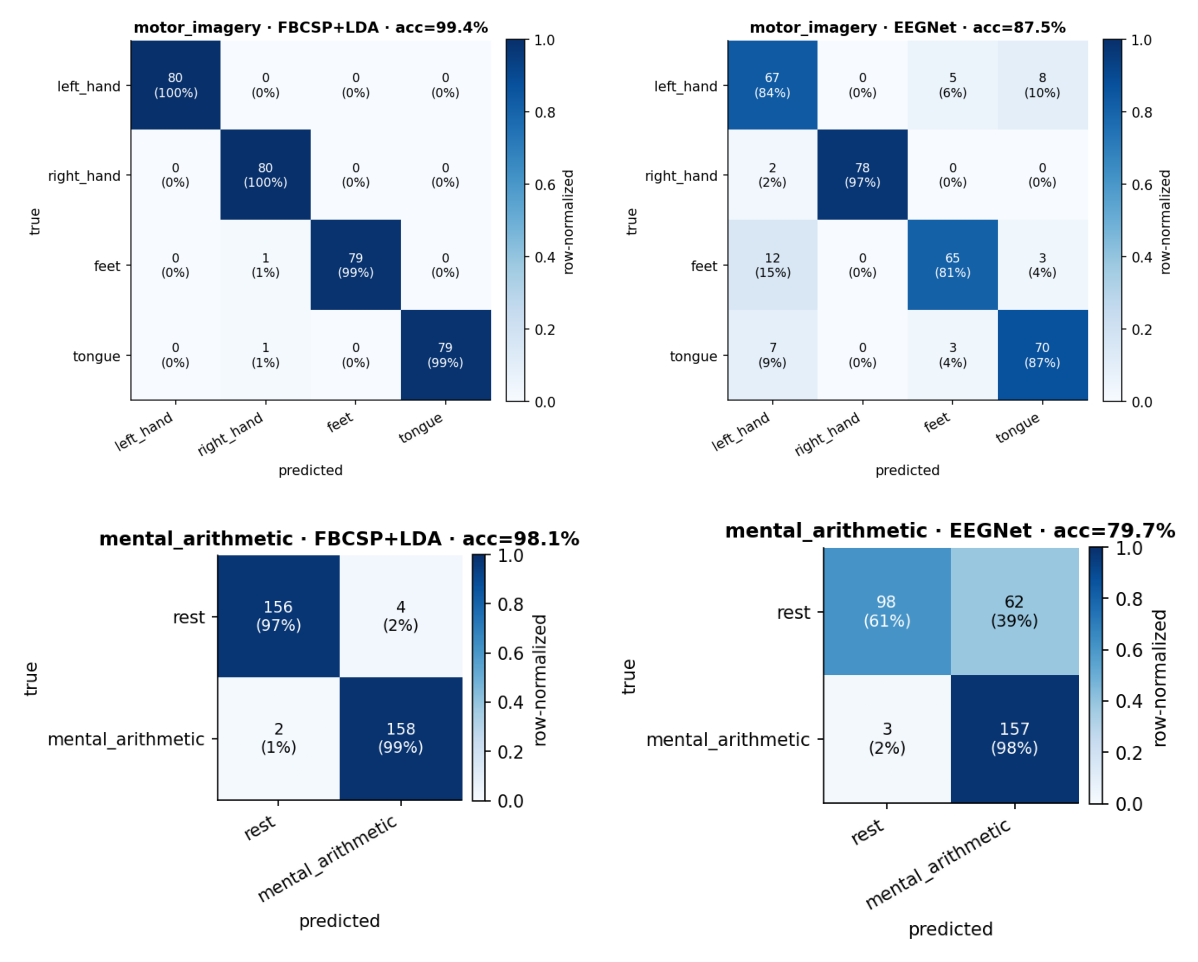

In [5]:
from eeg_cognitive.viz import plot_confusion_matrix
import matplotlib.image as mpimg

os.makedirs('../results/figures/notebook_outputs', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (dsn, m) in zip(axes.ravel(),
        [('motor_imagery','fbcsp'), ('motor_imagery','eegnet'),
         ('mental_arithmetic','fbcsp'), ('mental_arithmetic','eegnet')]):
    if (dsn, m) not in results:
        ax.axis('off'); continue
    d = results[(dsn, m)]
    name = 'FBCSP+LDA' if m == 'fbcsp' else 'EEGNet'
    title = f"{dsn} · {name} · acc={d['summary']['acc_mean']*100:.1f}%"
    out = f'../results/figures/notebook_outputs/06_cm_{dsn}_{m}.png'
    plot_confusion_matrix(np.array(d['confusion']), d['classes'], title, out)
    ax.imshow(mpimg.imread(out)); ax.axis('off')
plt.tight_layout(); plt.show()


## The cross-subject generalization gap

Train on subjects 0–2 of motor imagery, test on subject 3. The drop is
the cost of treating each new person's brain as a fresh distribution.

In [6]:
from eeg_cognitive import (make_motor_imagery_synthetic, preprocess_epochs,
                          ChannelStandardizer)
from eeg_cognitive.models import FBCSPClassifier, EEGNetClassifier
from sklearn.metrics import accuracy_score

mi = make_motor_imagery_synthetic(n_subjects=4, trials_per_class=20,
                                  snr_db=-12, seed=0)
Xall = preprocess_epochs(mi.X, mi.sfreq)
n = len(mi.y); per_subj = n // 4
sub_train = np.arange(0, 3 * per_subj)
sub_test = np.arange(3 * per_subj, 4 * per_subj)
sc = ChannelStandardizer().fit(Xall[sub_train])
Xa = sc.transform(Xall[sub_train]); ya = mi.y[sub_train]
Xb = sc.transform(Xall[sub_test]);  yb = mi.y[sub_test]

fb = FBCSPClassifier(sfreq=mi.sfreq, n_components=4, n_features=20).fit(Xa, ya)
en = EEGNetClassifier(epochs=30, batch_size=64, lr=1.5e-3, weight_decay=1e-4,
                      patience=12, val_frac=0.2, seed=0)
en.sfreq = mi.sfreq; en.eegnet_kernel_length = max(16, int(mi.sfreq // 4))
en.fit(Xa, ya)

print('CROSS-SUBJECT (train on subj 0-2, test on subj 3):')
print(f'  FBCSP  acc = {accuracy_score(yb, fb.predict(Xb))*100:5.1f} %')
print(f'  EEGNet acc = {accuracy_score(yb, en.predict(Xb))*100:5.1f} %')
print()
print('Compare to within-subject CV above. Both drop dramatically;')
print('EEGNet drops less. Capacity that hurt within-subject helps cross-subject.')


CROSS-SUBJECT (train on subj 0-2, test on subj 3):
  FBCSP  acc =  33.8 %


  EEGNet acc =  43.8 %

Compare to within-subject CV above. Both drop dramatically;
EEGNet drops less. Capacity that hurt within-subject helps cross-subject.
